In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score
import xgboost as xg
from sklearn.ensemble import RandomForestRegressor

In [6]:
df_state = pd.read_csv("/Users/hayashieijun/Desktop/CSE_881_Final_Project/data/raw/hhs_state_timeseries.csv")

In [7]:
df_state.head()

,state,date,critical_staffing_shortage_today_yes,critical_staffing_shortage_today_no,critical_staffing_shortage_today_not_reported,critical_staffing_shortage_anticipated_within_week_yes,critical_staffing_shortage_anticipated_within_week_no,critical_staffing_shortage_anticipated_within_week_not_reported,hospital_onset_covid,hospital_onset_covid_coverage,...,previous_day_admission_pediatric_covid_confirmed_5_11,previous_day_admission_pediatric_covid_confirmed_5_11_coverage,previous_day_admission_pediatric_covid_confirmed_unknown,previous_day_admission_pediatric_covid_confirmed_unknown_coverage,staffed_icu_pediatric_patients_confirmed_covid,staffed_icu_pediatric_patients_confirmed_covid_coverage,staffed_pediatric_icu_bed_occupancy,staffed_pediatric_icu_bed_occupancy_coverage,total_staffed_pediatric_icu_beds,total_staffed_pediatric_icu_beds_coverage
0,AL,2020-01-01T00:00:00.000,0,0,1,0,0,1,NaN,0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
1,HI,2020-01-01T00:00:00.000,0,0,1,0,0,1,0.0,1,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,IN,2020-01-01T00:00:00.000,0,0,1,0,0,1,0.0,1,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
3,LA,2020-01-01T00:00:00.000,0,0,1,0,0,1,NaN,0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
4,MN,2020-01-01T00:00:00.000,0,0,1,0,0,1,0.0,1,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


/var/folders/cq/hl3j32w16cb80bz20lcyxw4m0000gn/T/ipykernel_31522/2068080533.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')


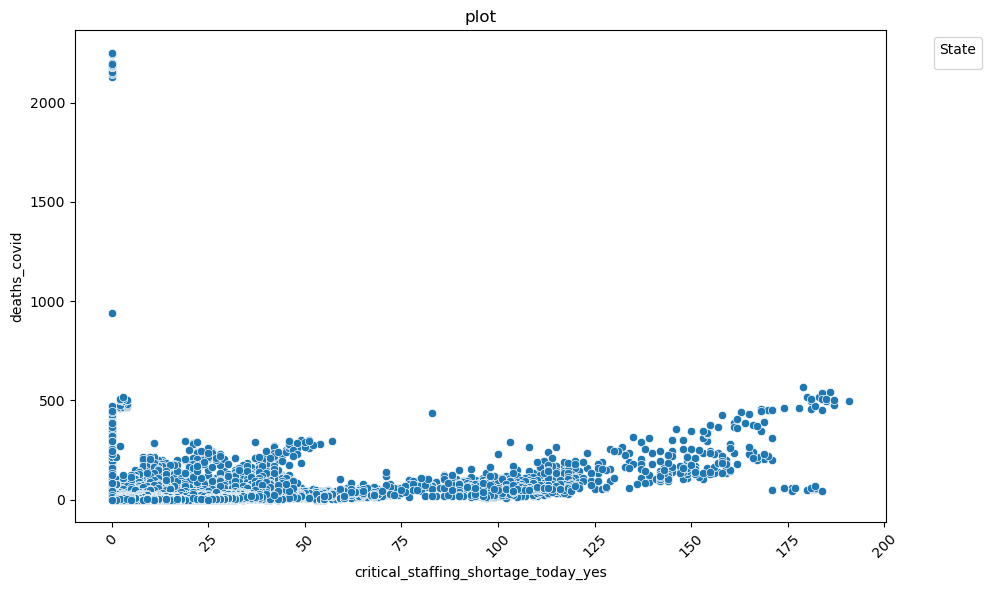

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_state, x='critical_staffing_shortage_today_yes', y='deaths_covid')
plt.title('plot')
plt.xlabel('critical_staffing_shortage_today_yes')
plt.ylabel('deaths_covid')
plt.xticks(rotation=45)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/cq/hl3j32w16cb80bz20lcyxw4m0000gn/T/ipykernel_31522/2156320246.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')


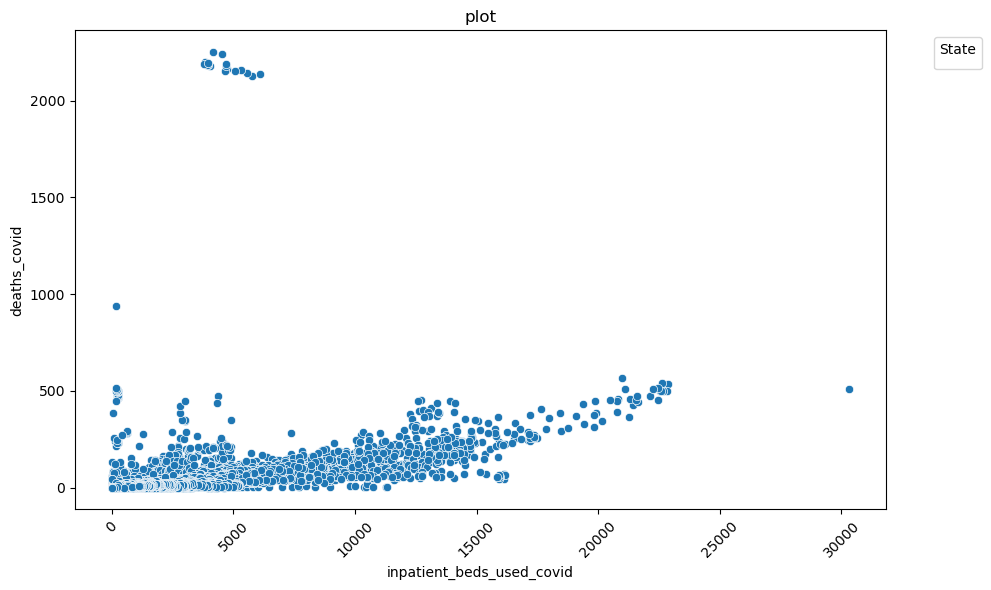

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_state, x='inpatient_beds_used_covid', y='deaths_covid')
plt.title('plot')
plt.xlabel('inpatient_beds_used_covid')
plt.ylabel('deaths_covid')
plt.xticks(rotation=45)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
to_delete = ['previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_coverage',
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'previous_day_admission_adult_covid_confirmed_18_19',
 'previous_day_admission_adult_covid_confirmed_18_19_coverage',
 'previous_day_admission_adult_covid_confirmed_20_29',
 'previous_day_admission_adult_covid_confirmed_20_29_coverage',
 'previous_day_admission_adult_covid_confirmed_30_39',
 'previous_day_admission_adult_covid_confirmed_30_39_coverage',
 'previous_day_admission_adult_covid_confirmed_40_49',
 'previous_day_admission_adult_covid_confirmed_40_49_coverage',
 'previous_day_admission_adult_covid_confirmed_50_59',
 'previous_day_admission_adult_covid_confirmed_50_59_coverage',
 'previous_day_admission_adult_covid_confirmed_60_69',
 'previous_day_admission_adult_covid_confirmed_60_69_coverage',
 'previous_day_admission_adult_covid_confirmed_70_79',
 'previous_day_admission_adult_covid_confirmed_70_79_coverage',
 'previous_day_admission_adult_covid_confirmed_80',
 'previous_day_admission_adult_covid_confirmed_80_coverage',
 'previous_day_admission_adult_covid_confirmed_unknown',
 'previous_day_admission_adult_covid_confirmed_unknown_coverage',
 'previous_day_admission_adult_covid_suspected_18_19',
 'previous_day_admission_adult_covid_suspected_18_19_coverage',
 'previous_day_admission_adult_covid_suspected_20_29',
 'previous_day_admission_adult_covid_suspected_20_29_coverage',
 'previous_day_admission_adult_covid_suspected_30_39',
 'previous_day_admission_adult_covid_suspected_30_39_coverage',
 'previous_day_admission_adult_covid_suspected_40_49',
 'previous_day_admission_adult_covid_suspected_40_49_coverage',
 'previous_day_admission_adult_covid_suspected_50_59',
 'previous_day_admission_adult_covid_suspected_50_59_coverage',
 'previous_day_admission_adult_covid_suspected_60_69',
 'previous_day_admission_adult_covid_suspected_60_69_coverage',
 'previous_day_admission_adult_covid_suspected_70_79',
 'previous_day_admission_adult_covid_suspected_70_79_coverage',
 'previous_day_admission_adult_covid_suspected_80_',
 'previous_day_admission_adult_covid_suspected_80_coverage',
 'previous_day_admission_adult_covid_suspected_unknown',
 'previous_day_admission_adult_covid_suspected_unknown_coverage',
 'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
 'previous_week_therapeutic_b_bamlanivimab_courses_used',
 'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
 'previous_day_admission_influenza_confirmed',
 'previous_day_admission_influenza_confirmed_coverage',
 'previous_day_deaths_covid_and_influenza',
 'previous_day_deaths_covid_and_influenza_coverage',
 'previous_day_deaths_influenza',
 'previous_day_deaths_influenza_coverage',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'previous_day_admission_pediatric_covid_confirmed_0_4',
 'previous_day_admission_pediatric_covid_confirmed_0_4_coverage',
 'previous_day_admission_pediatric_covid_confirmed_12_17',
 'previous_day_admission_pediatric_covid_confirmed_12_17_coverage',
 'previous_day_admission_pediatric_covid_confirmed_5_11',
 'previous_day_admission_pediatric_covid_confirmed_5_11_coverage',
 'previous_day_admission_pediatric_covid_confirmed_unknown',
 'previous_day_admission_pediatric_covid_confirmed_unknown_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']
df_state = df_state.drop(columns= to_delete)

In [11]:
# Removing these 3 columns as they are moderate and positively correlated  with inpatient beds used for covid
df_state = df_state.drop(columns = ["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses", 
               "on_hand_supply_therapeutic_b_bamlanivimab_courses"])

#Explains the same information as the percentage thats caculated with these numerators and denominators.
df_state = df_state.drop(columns = ["inpatient_beds_utilization_coverage", 
                        "inpatient_beds_utilization",
                        "percent_of_inpatients_with_covid",
                         "percent_of_inpatients_with_covid_coverage",
                         "inpatient_bed_covid_utilization",
                         "inpatient_bed_covid_utilization_coverage",
                         ])

In [12]:
#total hospital= inpatient_beds_used_coverage

# <font color=#00BBFF> Feature Engineering </font>

In [13]:
# Coverage per state (row wise)
df_state["coverage_per_state"] = df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"] + df_state["critical_staffing_shortage_today_not_reported"]
#feature engineering
 
# Normalized deaths per hostpital from covid 
df_state["deaths_covid"] = df_state["deaths_covid"] / (df_state["deaths_covid_coverage"] / df_state["coverage_per_state"])

# Staffing shortage ratio
df_state["state_staffing_shortage_ratio"] = df_state["critical_staffing_shortage_today_yes"] / (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"])

# Reporting completeness
df_state["state_staffing_reporting_completeness"] = (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"]) / (
    df_state["coverage_per_state"]
)

# Reporting for next week (staffing shortage) ratio
df_state["state_staffing_shortage_anticipation_ratio"] = df_state["critical_staffing_shortage_anticipated_within_week_yes"] / (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"])

# Reporting for next week (staffing shortage) completeness
df_state["state_staffing_shortage_anticipation_completeness"] = (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"]) / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"] + df_state["critical_staffing_shortage_anticipated_within_week_not_reported"] )

df_state = df_state.drop(columns = ["deaths_covid_coverage", "deaths_covid", "critical_staffing_shortage_anticipated_within_week_yes", "critical_staffing_shortage_anticipated_within_week_no",
                         "critical_staffing_shortage_anticipated_within_week_not_reported"])

In [14]:
# Normalized deaths per hostpital from covid 
df_state["hospital_onset_covid"] = df_state["hospital_onset_covid"] / (df_state["hospital_onset_covid_coverage"] / df_state["coverage_per_state"])

# Normalized beds total per hospital 
df_state["inpatient_beds"] = df_state["inpatient_beds"] / (df_state["inpatient_beds_coverage"] / df_state["coverage_per_state"])

# Normalized beds used per hospital 
df_state["inpatient_beds_used"] = df_state["inpatient_beds_used"] / (df_state["inpatient_beds_used_coverage"] / df_state["coverage_per_state"])

# Normalize inpatients beds used from covidper hospital 
df_state["inpatient_beds_used_covid"] = df_state["inpatient_beds_used_covid"] / (df_state["inpatient_beds_used_covid_coverage"] / df_state["coverage_per_state"])

# just influenza
df_state["icu_patients_confirmed_influenza"] = df_state["icu_patients_confirmed_influenza"] / (df_state["icu_patients_confirmed_influenza_coverage"] / df_state["coverage_per_state"])

#normalize count of total icu patients
df_state["total_patients_hospitalized_confirmed_influenza"] = df_state["total_patients_hospitalized_confirmed_influenza"] / (df_state["total_patients_hospitalized_confirmed_influenza_coverage"] / df_state["coverage_per_state"])

#Normalized count for covid plus influenza patients
df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] = df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] / (df_state["total_patients_hospitalized_confirmed_influenza_and_covid_coverage"] / df_state["coverage_per_state"])


df_state = df_state.drop(columns = ["hospital_onset_covid_coverage", "inpatient_beds_coverage", "inpatient_beds_used_coverage", "inpatient_beds_used_covid_coverage",
"icu_patients_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])

In [15]:
df_state = df_state.drop(columns = ["inpatient_beds_utilization_numerator",
"inpatient_beds_utilization_denominator",
'percent_of_inpatients_with_covid_numerator',
'percent_of_inpatients_with_covid_denominator',
'inpatient_bed_covid_utilization_numerator',
'inpatient_bed_covid_utilization_denominator', "critical_staffing_shortage_today_yes",
"critical_staffing_shortage_today_no", "critical_staffing_shortage_today_not_reported"]
       )


In [16]:
df_state.columns

Index(['state', 'date', 'hospital_onset_covid', 'inpatient_beds',
       'inpatient_beds_used', 'inpatient_beds_used_covid',
       'icu_patients_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness'],
      dtype='object')

# <font color=#00BBFF> Importance ranking </font>

In [17]:
import numpy as np
cor_matrix = df_state.select_dtypes(include=[np.number]).corr() #select only numerical columns
mass_correlations = cor_matrix['inpatient_beds_used'].sort_values(ascending=False) #Order the value from higher to lower
mass_correlations

inpatient_beds_used                                          1.000000
inpatient_beds                                               0.992394
coverage_per_state                                           0.878809
inpatient_beds_used_covid                                    0.689086
hospital_onset_covid                                         0.510072
total_patients_hospitalized_confirmed_influenza              0.411825
icu_patients_confirmed_influenza                             0.344447
total_patients_hospitalized_confirmed_influenza_and_covid    0.305906
state_staffing_reporting_completeness                        0.065579
state_staffing_shortage_anticipation_completeness           -0.003286
state_staffing_shortage_anticipation_ratio                  -0.069223
state_staffing_shortage_ratio                               -0.130222
Name: inpatient_beds_used, dtype: float64

In [18]:
# Drop the highly correlated feature
df_state = df_state.drop(columns=['inpatient_beds','coverage_per_state','inpatient_beds_used_covid'])

# <font color=#00BBFF> Convert Date and State </font>

In [19]:
#convert state to categorical
le = LabelEncoder()
df_state['state_encoded'] = le.fit_transform(df_state['state'])

In [20]:
#convert date to datetime and extract features
df_state['date'] = pd.to_datetime(df_state['date'])
df_state['day_of_week'] = df_state['date'].dt.dayofweek # Monday=0, Sunday=6
df_state['month'] = df_state['date'].dt.month
df_state['year'] = df_state['date'].dt.year

# <font color=#00BBFF> Train/Test </font>

Before imputing missing values, we should split the dataset first. Only imputing train data and then runn model to predict test data. Therefore, we can know the performance of model.
Split the data not at random, it should be based on day. We can split the first 80% data.

In [21]:
#Sort by date first to ensure chronological order
df_state = df_state.sort_values(['date'])
split_idx = int(len(df_state) * 0.8)
train_df = df_state.iloc[:split_idx]
test_df = df_state.iloc[split_idx:]

#Separate Features (X) and Target (y)
target = 'inpatient_beds_used'
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# <font color=#00BBFF> imputation </font>

In [22]:
#MICE imputation
df_train_num_col = X_train.select_dtypes(include=['int64', 'float64','int32'])
df_test_num_col = X_test.select_dtypes(include=['int64', 'float64','int32'])
#create iterative imputer with custom settings
mice_advanced = IterativeImputer(
    estimator=Ridge(),           #use Ridge regression instead of default
    max_iter=20,                 #more iterations for better accuracy
    random_state=42,             #for reproducibility
    initial_strategy='median',   #start with median instead of mean
    verbose=1                    #show progress
)

#fit and transform
df_train_mice = pd.DataFrame(
    mice_advanced.fit_transform(df_train_num_col), #avoid data leakage
    columns=df_train_num_col.columns,
    index=df_train_num_col.index
)

#Apply the same imputer to the test set
df_test_mice = pd.DataFrame(
    mice_advanced.transform(df_test_num_col), #avoid data leakage
    columns=df_test_num_col.columns,
    index=df_test_num_col.index
)

[IterativeImputer] Completing matrix with shape (65370, 12)
[IterativeImputer] Change: 296.784409186215, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 154.31661709357155, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 126.94006951598061, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 102.70181729215781, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 83.08976544905897, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 67.2201557773572, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 54.38186155138274, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 43.995243766430406, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 35.59220486725799, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 28.794079755662924, scaled tolerance: 2.2106694214876033 
[IterativeImputer] Change: 23.294386794930826, scaled tolerance: 2.2106694214876033 
[IterativeIm

/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [23]:
#Bayesian Ridge Imputer
br_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42
)

df_train_br = pd.DataFrame(br_imputer.fit_transform(df_train_num_col), columns=df_train_num_col.columns)
df_test_br = pd.DataFrame(br_imputer.transform(df_test_num_col), columns=df_test_num_col.columns)

/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [24]:
#impute missing values by filling with mean
df_train_mean = df_train_num_col.fillna(df_train_num_col.mean())
df_test_mean = df_test_num_col.fillna(df_train_num_col.mean()) #use train mean to avoid data leakage


In [25]:
#impute y_train by using interpolate()
y_train = y_train.interpolate(method='linear', limit_direction='both') 

In [41]:
df_train_mice.describe().T

,count,mean,std,min,25%,50%,75%,max
hospital_onset_covid,65370.0,24.855528,57.590041,-0.623118,2.000000,8.000000,23.676471,1637.181818
icu_patients_confirmed_influenza,65370.0,4.180174,13.097391,-7.636767,0.000000,1.000000,3.031579,276.972452
total_patients_hospitalized_confirmed_influenza,65370.0,31.782488,87.718448,-51.272387,1.166667,8.362723,25.351155,2210.669421
total_patients_hospitalized_confirmed_influenza_and_covid,65370.0,6.282911,23.520094,-6.003301,0.000000,1.033058,7.983577,878.986175
state_staffing_shortage_ratio,65370.0,0.139604,0.163668,-0.188380,0.041237,0.094737,0.184000,1.000000
state_staffing_reporting_completeness,65370.0,0.591518,0.390381,0.000000,0.155556,0.807692,0.941176,1.000000
state_staffing_shortage_anticipation_ratio,65370.0,0.177452,0.167099,-0.073049,0.066667,0.133333,0.242424,1.000000
state_staffing_shortage_anticipation_completeness,65370.0,0.736722,0.328915,0.000000,0.726619,0.875000,0.957346,1.000000
state_encoded,65370.0,26.674407,15.473326,0.000000,13.000000,27.000000,40.000000,53.000000
day_of_week,65370.0,2.998593,1.999410,0.000000,1.000000,3.000000,5.000000,6.000000


# <font color=#00BBFF> Modeling - Baseline </font>

**R2 score** : 

In [26]:
#Baseline Ridge Regression Model
baseline_model = Ridge()
baseline_model.fit(df_train_mice, y_train)

baseline_preds_mice = baseline_model.predict(df_test_mice)
print(f"Baseline R2 Score: {r2_score(y_test, baseline_preds_mice)}")

Baseline R2 Score: 0.4064472192468901


In [27]:
#Baseline Ridge Regression Model
baseline_model = Ridge()
baseline_model.fit(df_train_br, y_train)

baseline_preds_br = baseline_model.predict(df_test_br)
print(f"Baseline R2 Score: {r2_score(y_test, baseline_preds_br)}")

Baseline R2 Score: 0.4062685289143775


In [28]:
#Baseline Ridge Regression Model
baseline_model = Ridge()
baseline_model.fit(df_train_mean, y_train)

baseline_preds_mean = baseline_model.predict(df_test_mean)
print(f"Baseline R2 Score: {r2_score(y_test, baseline_preds_mean)}")

Baseline R2 Score: 0.4008986505105029


# <font color=#00BBFF> Modeling - XGBR </font>

In [29]:
#XGBR-MICE
xgb_model = xg.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
xgb_model.fit(df_train_mice, y_train)

xgb_preds_mice = xgb_model.predict(df_test_mice)
xgb_r2_mice = r2_score(y_test, xgb_preds_mice)

print(f"XGBoost R2 Score of MICE Imputation: {xgb_r2_mice}")

XGBoost R2 Score of MICE Imputation: 0.8731189391575205


In [30]:
#XGBR-Bayesian Ridge Imputer
xgb_model = xg.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
xgb_model.fit(df_train_br, y_train)

xgb_preds_br = xgb_model.predict(df_test_br)
xgb_r2_br = r2_score(y_test, xgb_preds_br)

print(f"XGBoost R2 Score of Bayesian Ridge Imputation: {xgb_r2_br}")

XGBoost R2 Score of Bayesian Ridge Imputation: 0.8839308103345661


In [31]:
#XGBR-Bayesian Ridge Imputer
xgb_model = xg.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
xgb_model.fit(df_train_mean, y_train)

xgb_preds_mean = xgb_model.predict(df_test_mean)
xgb_r2_mean = r2_score(y_test, xgb_preds_mean)

print(f"XGBoost R2 Score of mean: {xgb_r2_mean}")

XGBoost R2 Score of mean: 0.8829562240736208


# <font color=#00BBFF> Modeling - RFR </font>

In [32]:
#Random Forest Regressor - MICE
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

rf_model.fit(df_train_mice, y_train)

rf_preds_mice = rf_model.predict(df_test_mice)
rf_r2_mice = r2_score(y_test, rf_preds_mice)

print(f"Random Forest R2 of MICE: {rf_r2_mice}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.5s


Random Forest R2 of MICE: 0.782743290211145


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [33]:
#Random Forest Regressor - Bayesian Ridge Imputer
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

rf_model.fit(df_train_br, y_train)

rf_preds_br = rf_model.predict(df_test_br)
rf_r2_br = r2_score(y_test, rf_preds_br)

print(f"Random Forest R2 of Bayesian: {rf_r2_br}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.5s


Random Forest R2 of Bayesian: 0.7819273863179345


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [34]:
#Random Forest Regressor - Bayesian Ridge Imputer
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

rf_model.fit(df_train_mean, y_train)

rf_preds_mean = rf_model.predict(df_test_mean)
rf_r2_mean = r2_score(y_test, rf_preds_mean)

print(f"Random Forest R2 of mean: {rf_r2_mean}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.1s


Random Forest R2 of mean: 0.8137429082142921


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


# <font color=#00BBFF> Plots </font>

<Figure size 1000x600 with 0 Axes>

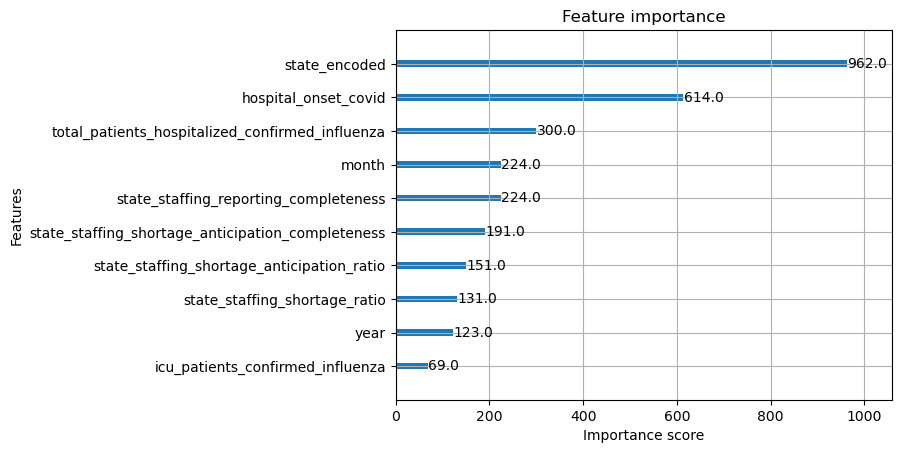

In [35]:
import matplotlib.pyplot as plt

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
xg.plot_importance(xgb_model, max_num_features=10)
plt.show()

In [38]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# 1. Initialize the TimeSeriesSplit
# n_splits=5 means it will test on 5 different sequential windows
tscv = TimeSeriesSplit(n_splits=5)

# 2. Initialize your model with your preferred parameters
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)

# 3. Perform Cross-Validation
# We use 'r2' since that is your primary metric
cv_results = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')

# 4. Output the results
print(f"R2 scores for each fold: {cv_results}")
print(f"Mean R2: {cv_results.mean():.4f}")
print(f"Standard Deviation: {cv_results.std():.4f}")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/xgboost/data.py", line 407, in pandas_feature_info
    new_feature_types.append(_pandas_dtype_mapper[dtype.name])
                             ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'object'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hayashieijun/De

In [36]:
import matplotlib.pyplot as plt

residuals = y_test - xgb_preds
plt.scatter(xgb_preds, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

NameError: name 'xgb_preds' is not defined